# Analysis of Oscar Nominated Movies 2000–2017
### Fall 2024 Data Science Project
Jack Burke – – 

Tal Ledeniov – – 

Ryan DeCamp – – 

Robert Hopkins – A, B, C, G, H – Organized the merging of team members' work for Checkpoints 2 and 3. Performed final reviews & submissions of assignments. "Tutorial-ized" much of Checkpoint 3. Led data processing. 

## Introduction

The objective of this project is to guide readers through the data science lifecycle, as we analyze ....

Through this tutorial, readers should learn enough to complete each step of the data science life cycle for *their own* problem they'd like to solve. The steps in the data science lifecycle are as follows:
- Data collection
- Data processing
- Exploratory analysis & visualization
- Analysis, hypothesis testing, & ML
- Insight & decision making

## Data Curation

The first step is of course collecting data. Data can either be collected firsthand directly from a source (primary) or can involve use of pre-existing sources that have already been collected and published for public use (secondary). For this project, we'll be using *secondary* data collection, which is less costly in terms of time and money. 

The data that we'll be using for our tutorial today is from [Kaggle](https://kaggle.com), a great place to find tons of data on tons of different topics. The dataset we'll use is [Oscar nominated Movies 2000–2017](https://www.kaggle.com/datasets/vipulgote4/oscars-nominated-movies-from-2000-to-2017), published by user *Overfitted*, sourced from [IMDB.com](https://IMDB.com)

Kaggle unfortunately requires users to create an account to download data, so the CSV is provided [(download link)](oscar_movies.csv) for this tutorial.

Now, let's get this into a Pandas *DataFrame* so we can work with the data in Python! 

In [123]:
# First, we'll import the packages we need for now and for later. 
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

The packages imported above are so fundamental they break the general Python style rule that says you shouldn't use `import ... as ...`. People know what `pd`, `np`, and the others are, so it's OK! 

In [124]:
# import from local file system. 
# (assumes that your .py or .ipynb file is in the same folder as the .csv file.)
movie_df = pd.read_csv("./oscar_movies.csv")
movie_df.head() # DataFrame.head() shows the first few rows of the dataframe.

,year,movie,movie_id,certificate,duration,genre,rate,metascore,synopsis,votes,...,New_York_Film_Critics_Circle_nominated,New_York_Film_Critics_Circle_nominated_categories,Los_Angeles_Film_Critics_Association_won,Los_Angeles_Film_Critics_Association_won_categories,Los_Angeles_Film_Critics_Association_nominated,Los_Angeles_Film_Critics_Association_nominated_categories,release_date.year,release_date.month,release_date.day-of-month,release_date.day-of-week
0,2001,Kate & Leopold,tt0035423,PG-13,118,Comedy|Fantasy|Romance,6.4,44.0,An English Duke from 1876 is inadvertedly drag...,66660,...,0,NaN,0,NaN,0,NaN,2001.0,12.0,25.0,2.0
1,2000,Chicken Run,tt0120630,G,84,Animation|Adventure|Comedy,7.0,88.0,When a cockerel apparently flies into a chicke...,144475,...,1,Best Animated Film,1,Best Animation,1,Best Animation,2000.0,6.0,23.0,5.0
2,2005,Fantastic Four,tt0120667,PG-13,106,Action|Adventure|Family,5.7,40.0,A group of astronauts gain superpowers after a...,273203,...,0,NaN,0,NaN,0,NaN,2005.0,7.0,8.0,5.0
3,2002,Frida,tt0120679,R,123,Biography|Drama|Romance,7.4,61.0,"A biography of artist Frida Kahlo, who channel...",63852,...,0,NaN,0,NaN,0,NaN,2002.0,11.0,22.0,5.0
4,2001,The Lord of the Rings: The Fellowship of the Ring,tt0120737,PG-13,178,Adventure|Drama|Fantasy,8.8,92.0,A meek Hobbit from the Shire and eight compani...,1286275,...,0,NaN,1,Best Music,2,Best Music|Best Production Design,2001.0,12.0,19.0,3.0


Now that we have our data *directly* from the Kaggle source, we can get to some *real* data science.

### Data Processing

Actually, we need to prepare our data before we can analyze it. The purpose of this is to make our data easy to work with and to remedy any errors that may or may not have seeped in. The last thing we want is to draw faulty conclusions from faulty data. Let's get cleaning.

After making sure that we don't have any duplicate entries, we'll go through and change some data types (and perform other small, quick fixes) to make things easy to work with. 
- Convert flags to booleans
- Metascore to int
- Convert dates to datetime types
- Re-align day-of-week to be 0-indexed
- Convert "release_date.____" columns to int
- Convert lists to list types (genre, _categories)

In [125]:
assert len(movie_df[movie_df.duplicated()]) == 0 # Make sure all IDs are unique

# This shows us movies with the same names. 
# Movies are allowed to have the same name, so these are OK. 
movie_df[movie_df.duplicated("movie", keep=False)]

,year,movie,movie_id,certificate,duration,genre,rate,metascore,synopsis,votes,...,New_York_Film_Critics_Circle_nominated,New_York_Film_Critics_Circle_nominated_categories,Los_Angeles_Film_Critics_Association_won,Los_Angeles_Film_Critics_Association_won_categories,Los_Angeles_Film_Critics_Association_nominated,Los_Angeles_Film_Critics_Association_nominated_categories,release_date.year,release_date.month,release_date.day-of-month,release_date.day-of-week
484,2006,The Illusionist,tt0443543,PG-13,110,Drama|Mystery|Romance,7.6,68.0,"In turn-of-the-century Vienna, a magician uses...",304063,...,0,NaN,0,NaN,0,NaN,2006.0,9.0,1.0,5.0
588,2010,The Illusionist,tt0775489,PG,80,Animation|Drama,7.5,82.0,A French illusionist finds himself out of work...,29236,...,1,Best Animated Film,0,NaN,1,Best Animation,2011.0,2.0,11.0,5.0


Oscars, as the most important prestigious type of award for films, and the focus of this dataset, are *each* represented for each movie with a unique flag. That means that movie XXXX has a series of "Yes" and "No" for Best Picture, Best International, .... We want it to be boolean types, not strings.

In [126]:
# Convert Oscar flags to bools instead of "Yes", "No" strings. 
for column in movie_df.columns:
    # get relevant Oscar flag columns
    if column.startswith("Oscar_") and column not in ["Oscar_nominated", "Oscar_nominated_categories"]:
        movie_df[column] = movie_df[column].replace({"Yes": True, "No": False})

movie_df["Oscar_Best_Picture_won"].dtype

dtype('bool')

Metascore is an integer, but the column is a float! Let's fix it.

In [127]:
# Convert metascore to int.
movie_df["metascore"] = pd.to_numeric(movie_df["metascore"], errors='coerce').astype('Int64')

movie_df[movie_df["metascore"].isna()][["movie"]] # 13 movies are missing metascores. Unpopular movies. 

,movie
88,Ken Park
272,Twin Sisters
348,The Room
380,As It Is in Heaven
450,Yesterday
474,The Queen
577,Beaufort
652,Unthinkable
669,"Angus, Thongs and Perfect Snogging"
700,Death Proof


Datetime types are provided by the datetime module, and pandas gives us an easy way to convert to datetime type. The type lets us do convenient things with dates that would be more difficult as a string or a series of numbers, so it's typical to use it.

In [128]:
# Convert "release_date" column to datetime types
movie_df["release_date"] = pd.to_datetime(movie_df["release_date"], dayfirst=False)

movie_df["release_date"].dtype
# dtype('<M8[ns]') is a datetype type

dtype('<M8[ns]')

In [129]:
# Align "release_date.day-of-week", the following is what we want.
"""
0: mon
1: tues
2: wed
3: thurs
4: fri (most common)
5: sat
6: sun
"""

movie_df["release_date.day-of-week"] -= 1

Years, months (represented numerically), dates, and days-of-week (represented like above) are integers, not floats. We want our data to reflect that. 

In [130]:
# Replace non-finite values with NaN, and convert to integers where possible
movie_df[["release_date.year", "release_date.month", "release_date.day-of-month", "release_date.day-of-week"]] = (
    movie_df[["release_date.year", "release_date.month", "release_date.day-of-month", "release_date.day-of-week"]]
    .astype('Int64')  # Convert to nullable integer type (preserves NaN)
)


Python has a native list type, but CSVs do not! The creator of this database elected to represent lists, instead of [a, b, c], like a|b|c. This is fine, but we want to change it so that we can work with them in Python.

In [131]:
# Convert "categories" nominated/won from "|"-delimited strings to lists of strings
for column in movie_df.columns:
    if "categories" in column:
        # Convert to list if string, if already list then keep as list, otherwise empty list (no nominations)
        movie_df[column] = movie_df[column].apply(lambda entry: entry.split("|") if isinstance(entry, str) else (entry if isinstance(entry, list) else []))

# Sanity check: make sure each entry length matches (for oscar at least)
oscar_mismatch_rows = movie_df[movie_df['Oscar_nominated_categories'].apply(len) != movie_df['Oscar_nominated']]
oscar_mismatch_rows[["Oscar_nominated_categories", "Oscar_nominated"]]

,Oscar_nominated_categories,Oscar_nominated


In [132]:
# convert "genre" from "|"-delimited strings into lists of strings
assert movie_df["genre"].isna().sum() == 0 # luckily, every movie has a genre already

# convert to list if string, if already list then keep as list, otherwise empty list (should never happen)
movie_df["genre"] = movie_df["genre"].apply(lambda entry: entry.split("|") if isinstance(entry, str) else (entry if isinstance(entry, list) else []))

assert all (movie_df["genre"].apply(lambda x: len(x) > 0 and isinstance(x, list))) # confirm all entries still have a genre and that all are lists

movie_df["genre"]

0           [Comedy, Fantasy, Romance]
1       [Animation, Adventure, Comedy]
2          [Action, Adventure, Family]
3          [Biography, Drama, Romance]
4          [Adventure, Drama, Fantasy]
                     ...              
1178                  [Drama, Romance]
1179                  [Drama, Romance]
1180       [Biography, Drama, History]
1181                    [Crime, Drama]
1182       [Biography, Drama, History]
Name: genre, Length: 1183, dtype: object

Just out of curiosity, let's get and print out all of the genres.

In [133]:
# Extract all unique genres from the 'genre' column
all_genres = set()

for genres in movie_df["genre"].dropna():
    # Add each genre to the set
    all_genres.update(genres)

# Convert the set to a sorted list and print
sorted_genres = sorted(all_genres)
print(sorted_genres)

['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Histor', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Sport', 'Thriller', 'War', 'Western']


Now that the easy part of the preprocessing is complete, we can move on to the more difficult part. Actually filling in missing information. 
- Missing release dates
- Missing popularity
- Missing grosses
- Missing reviews (users, critics)
- Missing rating (G, PG-13, R, ...)

Some movies have missing release dates. We can find out how many below. 

In [134]:
# Get movies without entered release dates
movie_df[movie_df["release_date"].isna()]["movie"]

1045                                     Mudbound
1060                                       Wonder
1165                                    Lady Bird
1169    Three Billboards Outside Ebbing, Missouri
1173                                     Marshall
1177                          The Florida Project
1178                         Call Me by Your Name
1179                               Phantom Thread
1181                        Roman J. Israel, Esq.
Name: movie, dtype: object

Since it's so few, we can just manually fill in the data from IMDB to mimic the original database as closely as possible. 

In [135]:
# Then we manually fix these using IMDB data, matching the original database. 
movie_release_dict = {
    "Mudbound": pd.to_datetime("2017-11-17", yearfirst=True, dayfirst=False),
    "Wonder": pd.to_datetime("2017-11-17", yearfirst=True, dayfirst=False),
    "Lady Bird": pd.to_datetime("2017-12-1", yearfirst=True, dayfirst=False),
    "Three Billboards Outside Ebbing, Missouri": pd.to_datetime("2017-12-1", yearfirst=True, dayfirst=False),
    "Marshall": pd.to_datetime("2017-10-13", yearfirst=True, dayfirst=False),
    "The Florida Project": pd.to_datetime("2017-11-10", yearfirst=True, dayfirst=False),
    "Call Me by Your Name": pd.to_datetime("2018-1-19", yearfirst=True, dayfirst=False),
    "Phantom Thread": pd.to_datetime("2018-1-19", yearfirst=True, dayfirst=False),
    "Roman J. Israel, Esq.": pd.to_datetime("2017-11-22", yearfirst=True, dayfirst=False),
}

# fill missing release dates
no_release_date = movie_df["release_date"].isna()
movie_df.loc[no_release_date, "release_date"] = movie_df["movie"].map(movie_release_dict)

# Extract year, month, and day only for the rows in no_release_date
movie_df.loc[no_release_date, "release_date.year"] = movie_df["release_date"].dt.year
movie_df.loc[no_release_date, "release_date.month"] = movie_df["release_date"].dt.month
movie_df.loc[no_release_date, "release_date.day-of-month"] = movie_df["release_date"].dt.day

# NOTE: datetime package uses 0 as Monday, 6 as Sunday. CSV uses 1 as Monday and 7 as Sunday.  
# That's why we changed to datetime package's way earlier! 
# When adding new weekdays,we can just use datetime's dt.weekday.
movie_df.loc[movie_df["release_date.day-of-week"].isna(), "release_date.day-of-week"] = movie_df["release_date"].dt.weekday

movie_df[["release_date", "release_date.year", "release_date.month", "release_date.day-of-month", "release_date.day-of-week"]]

,release_date,release_date.year,release_date.month,release_date.day-of-month,release_date.day-of-week
0,2001-12-25,2001,12,25,1
1,2000-06-23,2000,6,23,4
2,2005-07-08,2005,7,8,4
3,2002-11-22,2002,11,22,4
4,2001-12-19,2001,12,19,2
...,...,...,...,...,...
1178,2018-01-19,2018,1,19,4
1179,2018-01-19,2018,1,19,4
1180,2017-10-06,2017,10,6,4
1181,2017-11-22,2017,11,22,2


A movie's *popularity* is an IMDB-specific statistic that's based on when the movie was scraped. 1 is the most popular movie on IMDB at the time, and a higher number means less popular. Because the score depends on when the data was scraped, we can't manually fill in missing data. Additionally, Moana being there suggests that we're not dealing with *super* unpopular movies. 
For this project, we're going to ignore popularity for those reasons.  

In [136]:
print(sum(movie_df["popularity"].isna()))
print(movie_df[movie_df["popularity"].isna()][["movie"]])

119
                           movie
25             Nowhere in Africa
54                       Pollock
56                   Wonder Boys
64         Shadow of the Vampire
67                         Vatel
...                          ...
1116             A Monster Calls
1121                        Sing
1124                       Moana
1130       The Girl on the Train
1171  Jim: The James Foley Story

[119 rows x 1 columns]


Some films are missing reviews and metacores, but thankfully the number is quite small. We have over a thousand movies, remember. 
**Un**luckily, we can't fill these stats in now since more reviews (especially from users) have come in since scraping. This is another IMDB specific stat. 

In [137]:
# movies without user reviews also have no critic reviews!
print(movie_df[movie_df["user_reviews"].isna()][["movie", "user_reviews"]]) # 7 missing
print(movie_df[movie_df["critic_reviews"].isna()][["movie", "critic_reviews"]]) # 7 missing

# ...
print(movie_df[movie_df["metascore"].isna()][["movie", "metascore"]]) # 14 missing, disjoint from previous group

                                        movie  user_reviews
574                     Letters from Iwo Jima           NaN
1094                                  Inferno           NaN
1104  Fantastic Beasts and Where to Find Them           NaN
1116                          A Monster Calls           NaN
1121                                     Sing           NaN
1124                                    Moana           NaN
1130                    The Girl on the Train           NaN
                                        movie  critic_reviews
574                     Letters from Iwo Jima             NaN
1094                                  Inferno             NaN
1104  Fantastic Beasts and Where to Find Them             NaN
1116                          A Monster Calls             NaN
1121                                     Sing             NaN
1124                                    Moana             NaN
1130                    The Girl on the Train             NaN
                        

10 movies do not have a "rating" entry. For 8 of these, we can manually fill it in from IMDB. (Not Rated is different from not having a rating at all.)

In [138]:
# Manually assign ratings (luckily these are all considered "Not Rated".)
movie_df.loc[movie_df["movie_id"] == "tt0382330", "certificate"] = "Not Rated"
movie_df.loc[movie_df["movie_id"] == "tt0426578", "certificate"] = "Not Rated"
movie_df.loc[movie_df["movie_id"] == "tt0879843", "certificate"] = "Not Rated"
movie_df.loc[movie_df["movie_id"] == "tt1077262", "certificate"] = "Not Rated"
movie_df.loc[movie_df["movie_id"] == "tt1337193", "certificate"] = "Not Rated"
movie_df.loc[movie_df["movie_id"] == "tt2852406", "certificate"] = "Not Rated"
movie_df.loc[movie_df["movie_id"] == "tt3170902", "certificate"] = "Not Rated"
movie_df.loc[movie_df["movie_id"] == "tt4239726", "certificate"] = "Not Rated"

movie_df[movie_df["certificate"].isna()][["movie", "movie_id", "year", "certificate"]]

# Twilight Samurai and Milk of Sorrow are not classified as "Not Rated", their rating truly does not exist.


,movie,movie_id,year,certificate
319,The Twilight Samurai,tt0351817,2002,NaN
766,The Milk of Sorrow,tt1206488,2009,NaN


Lastly, some movies are missing US & Canada box office grosses. Thankfully, a movie's gross does not change very much after it's released, since its no longer being played in the theaters! For that reason, we felt comfortable manually filling in the grosses that were available on IMDB. Some remain unavailable.  

In [139]:
# fill in missing grosses manually
# grosses are found on IMDB's Gross US & Canada rounded to the nearest $10k

gross_fill_dict = { # manually built from IMDB website (imdb.com)
    'Lagaan: Once Upon a Time in India': 909043,
    # 'Ken Park': 0, (missing US & Canada data)
    'Zus & zo': 49468,
    'The Twilight Samurai': 559765,
    'The Room': 549602,
    # 'Yesterday': 0, (missing US & Canada data)
    # 'Unthinkable': 0, (missing US & Canada data)
    # 'Angus, Thongs and Perfect Snogging': 0, (missing US & Canada data)
    # 'Death Proof': 0, (missing US & Canada data)
    # "Hachi: A Dog's Tale": 0, (missing US & Canada data)
    'Revanche': 258388,
    'Outside the Law': 96933,
    'Secret in Their Eyes': 20180155,
    'The Great Wall': 45540830,
    # 'Mudbound': 0, (missing US & Canada data)
    'Leviathan': 1092800,
    'Omar': 356000,
    'Trumbo': 7857741,
    'The Autopsy of Jane Doe': 10474,
    'Elle': 2341534,
    'Land of Mine': 435266,
    # 'The Girl with All the Gifts': 0, (missing US & Canada data)
    'Split': 138291365,
    # 'Jim: The James Foley Story': 0 (missing US & Canada data)
}
# round to $10k
gross_fill_dict = {key: round(value, -4) for key, value in gross_fill_dict.items()}


movie_df.loc[movie_df["gross"].isna(), "gross"] = movie_df["movie"].map(gross_fill_dict)

assert sum(movie_df["gross"].isna()) == 9

movie_df[movie_df["gross"].isna()][["year", "movie", "gross"]]

,year,movie,gross
88,2002,Ken Park,NaN
450,2004,Yesterday,NaN
652,2010,Unthinkable,NaN
669,2008,"Angus, Thongs and Perfect Snogging",NaN
700,2007,Death Proof,NaN
701,2009,Hachi: A Dog's Tale,NaN
1045,2017,Mudbound,NaN
1158,2016,The Girl with All the Gifts,NaN
1171,2016,Jim: The James Foley Story,NaN


Lastly, we want to note that for several awards providers, there is missing data in the `_categories` columns. These are: 
- BAFTA
- LA Film Critics Association
- Austin Film Critics Association
- Hollywood Film
Thankfully, our analysis will focus on Oscars, but it's important to make sure when performing data analysis that you know what kind of data is there and what kind of data is missing. 

In [140]:
# Numerous '_categories' entries are missing. Too numerous to add manually.
# However, the '_won' and '_nominated' *non '_category'* columns appear accurate following manual investigation.

# Bafta
movies_with_zero_length_bafta_element = movie_df[movie_df["BAFTA_nominated_categories"].apply(lambda x: any(len(elem) == 0 for elem in x))]
movies_with_zero_length_bafta_element[["movie", "BAFTA_won", "BAFTA_won_categories", "BAFTA_nominated", "BAFTA_nominated_categories"]]
print(len(movies_with_zero_length_bafta_element))

# LAFC
movies_with_zero_length_lafc_element = movie_df[movie_df["Los_Angeles_Film_Critics_Association_nominated_categories"].apply(lambda x: any(len(elem) == 0 for elem in x))]
movies_with_zero_length_lafc_element[["movie", "Los_Angeles_Film_Critics_Association_won", "Los_Angeles_Film_Critics_Association_won_categories", "Los_Angeles_Film_Critics_Association_nominated", "Los_Angeles_Film_Critics_Association_nominated_categories"]]
print(len(movies_with_zero_length_lafc_element))

# Austin
movies_with_zero_length_austin_element = movie_df[movie_df["Austin_Film_Critics_Association_nominated_categories"].apply(lambda x: any(len(elem) == 0 for elem in x))]
movies_with_zero_length_austin_element[["movie", "Austin_Film_Critics_Association_won", "Austin_Film_Critics_Association_won_categories", "Austin_Film_Critics_Association_nominated", "Austin_Film_Critics_Association_nominated_categories"]]
print(len(movies_with_zero_length_austin_element))

# Hollywood
movies_with_zero_length_hollywood_element = movie_df[movie_df["Hollywood_Film_nominated_categories"].apply(lambda x: any(len(elem) == 0 for elem in x))]
movies_with_zero_length_hollywood_element[["movie", "Hollywood_Film_won", "Hollywood_Film_won_categories", "Hollywood_Film_nominated", "Hollywood_Film_nominated_categories"]]
print(len(movies_with_zero_length_hollywood_element))

103
6
12
9


Finally, we can view our summary statistics now that all our data is ready for analysis. 

In [141]:
movie_df.describe() # Convenient method on dataframes

,year,duration,rate,metascore,votes,gross,user_reviews,critic_reviews,popularity,awards_wins,...,Boston_Society_of_Film_Critics_won,Boston_Society_of_Film_Critics_nominated,New_York_Film_Critics_Circle_won,New_York_Film_Critics_Circle_nominated,Los_Angeles_Film_Critics_Association_won,Los_Angeles_Film_Critics_Association_nominated,release_date.year,release_date.month,release_date.day-of-month,release_date.day-of-week
count,1183.000000,1183.000000,1183.000000,1169.0,1.183000e+03,1.174000e+03,1176.000000,1176.000000,1064.000000,1183.000000,...,1183.000000,1183.000000,1183.000000,1183.000000,1183.000000,1183.00000,1183.0,1183.0,1183.0,1183.0
mean,2008.189349,116.176669,7.045478,63.744226,1.925260e+05,8.518425e+07,568.876701,269.219388,1296.877820,2.894336,...,0.165680,0.319527,0.146238,0.313609,0.180051,0.32967,2008.389687,6.754015,16.015216,3.699915
std,5.019049,19.615381,0.826094,16.9733,1.912311e+05,1.009022e+08,564.816928,144.088080,1019.818482,6.237800,...,0.582839,0.886646,0.513523,0.841324,0.574890,0.89340,5.019872,3.703181,8.320552,0.744108
min,2000.000000,70.000000,2.400000,9.0,5.070000e+02,1.207000e+03,3.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,2000.0,1.0,1.0,0.0
25%,2004.000000,102.000000,6.600000,51.0,6.550700e+04,1.509500e+07,219.000000,165.000000,524.750000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,2004.0,3.0,9.0,4.0
50%,2008.000000,114.000000,7.100000,65.0,1.402320e+05,5.194000e+07,408.000000,239.000000,1088.500000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,2008.0,7.0,16.0,4.0
75%,2013.000000,128.000000,7.600000,77.0,2.631190e+05,1.185900e+08,709.750000,351.000000,1772.750000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,2013.0,10.0,23.0,4.0
max,2017.000000,224.000000,9.000000,100.0,1.743331e+06,9.366300e+08,5078.000000,816.000000,4937.000000,49.000000,...,5.000000,6.000000,5.000000,6.000000,5.000000,7.00000,2018.0,12.0,31.0,6.0


## Exploratory Data Analysis

### Exploration 1

For this first exploration, we'll take a simple look at whether Oscar noms and IMDB ratings are correlated, and how!

In [142]:
exploration_1_movie_df = movie_df.copy()

#### Basic Data Summary and Exploration
To analyze the main characteristics of the dataset, we check the distribution of movie ratings.

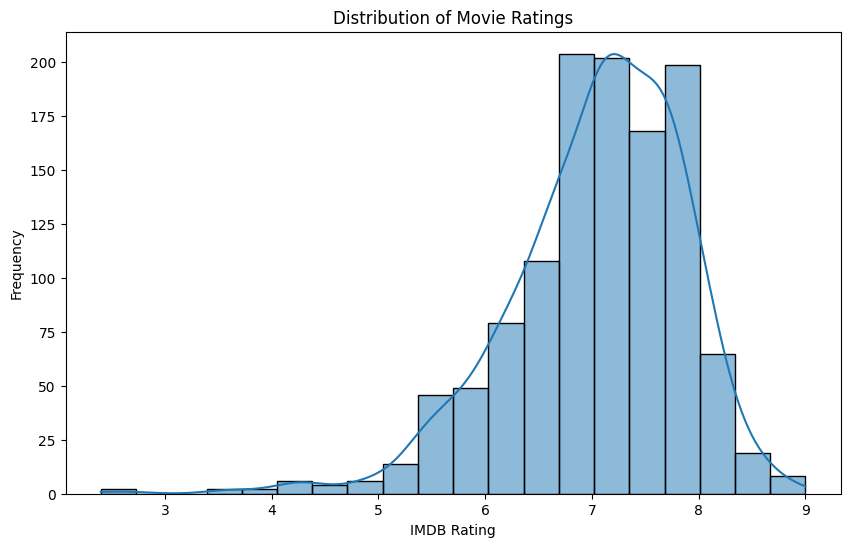

In [143]:
plt.figure(figsize=(10, 6))
sns.histplot(exploration_1_movie_df['rate'], bins=20, kde=True)
plt.title('Distribution of Movie Ratings')
plt.xlabel('IMDB Rating')
plt.ylabel('Frequency')
plt.show()

Now let's get basic summary statistics for Oscar-nominated and Non-Oscar-nominated movies to see what's up. 

In [144]:
oscar_nom = exploration_1_movie_df[movie_df['Oscar_nominated'] > 0]['rate']
non_oscar_nom = exploration_1_movie_df[movie_df['Oscar_nominated'] == 0]['rate']

print("Summary Statistics for Oscar-Nominated Movies:")
print(oscar_nom.describe())
print("\nSummary Statistics for Non-Oscar-Nominated Movies:")
print(non_oscar_nom.describe())

Summary Statistics for Oscar-Nominated Movies:
count    632.000000
mean       7.419462
std        0.632694
min        4.000000
25%        7.100000
50%        7.500000
75%        7.800000
max        9.000000
Name: rate, dtype: float64

Summary Statistics for Non-Oscar-Nominated Movies:
count    551.000000
mean       6.616515
std        0.813812
min        2.400000
25%        6.200000
50%        6.700000
75%        7.100000
max        8.500000
Name: rate, dtype: float64


We see there is a near-even split in the data, with the Oscar-nominated movies having a generally higher rating.

Let's see how the distribution looks visually. 

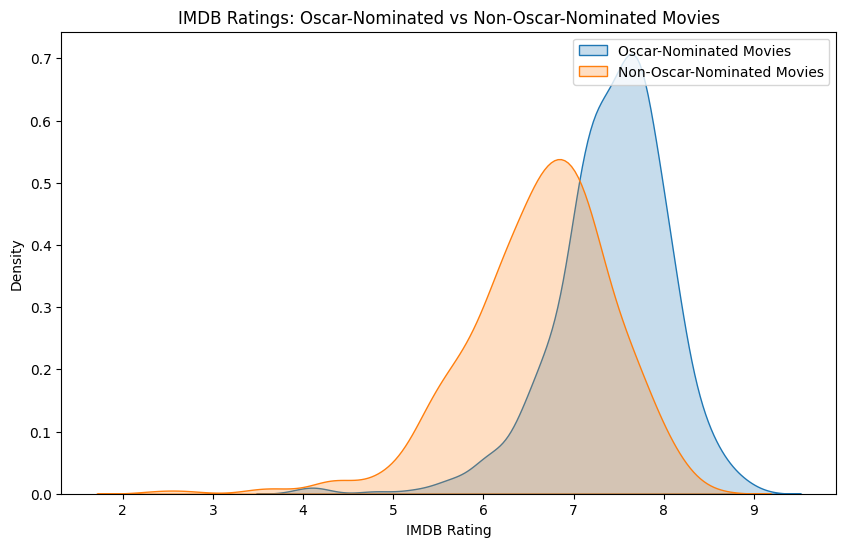

In [145]:
plt.figure(figsize=(10, 6))
sns.kdeplot(oscar_nom, label='Oscar-Nominated Movies', fill=True)
sns.kdeplot(non_oscar_nom, label='Non-Oscar-Nominated Movies', fill=True)
plt.title('IMDB Ratings: Oscar-Nominated vs Non-Oscar-Nominated Movies')
plt.xlabel('IMDB Rating')
plt.ylabel('Density')
plt.legend()
plt.show()

Instead of checking number of Oscar noms, we'll make a column that's true for those with nominations and false for those without. That just makes things a little easier for us later on.

In [146]:
#For the future plots, it will be easier to create a column in the movie_df that has true if Oscar_nominated>0 and false otherwise
exploration_1_movie_df['Oscar_nominations'] = exploration_1_movie_df['Oscar_nominated'] > 0
display(exploration_1_movie_df[['Oscar_nominated', 'Oscar_nominations']])

,Oscar_nominated,Oscar_nominations
0,1,True
1,0,False
2,0,False
3,6,True
4,13,True
...,...,...
1178,4,True
1179,6,True
1180,2,True
1181,1,True


Boxplot Comparison: IMDB Ratings (Oscar-Nominated vs Non-Nominated)")


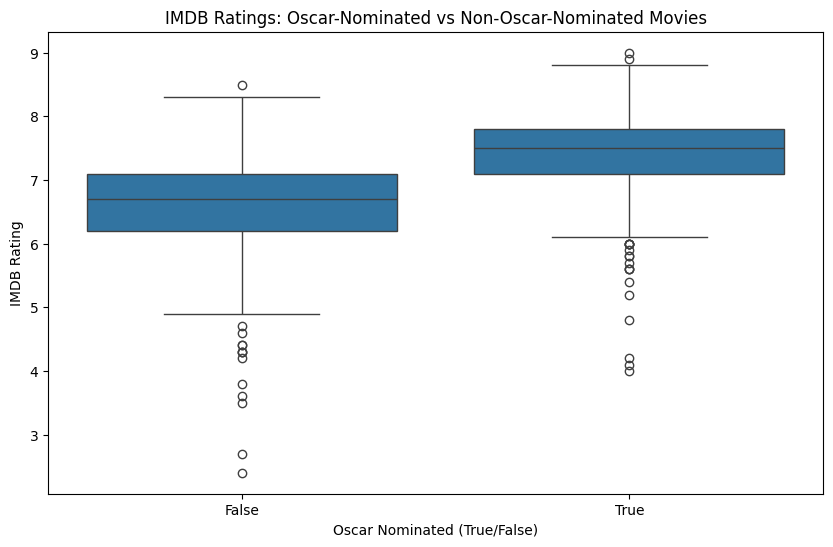

In [147]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Oscar_nominations', y='rate', data=exploration_1_movie_df)
plt.title('IMDB Ratings: Oscar-Nominated vs Non-Oscar-Nominated Movies')
plt.xlabel('Oscar Nominated (True/False)')
plt.ylabel('IMDB Rating')
plt.show()

Now let's do some hypothesis testing to compare the means of the two groups. 
Our null hypothesis is that there's no statistically significant difference in ratings between Oscar-nom movies and Non-Oscar-nom movies. 
Our alternative hypothesis then is that there *is* a statstically significant difference in ratings. 

In [148]:
from scipy import stats

In [149]:
t_stat, p_val = stats.ttest_ind(oscar_nom, non_oscar_nom, nan_policy='omit')

print(f"T-statistic: {t_stat}, P-value: {p_val}")

if p_val < 0.05:
    print("There is a statistically significant difference in ratings between Oscar-Nominated and non-Oscar-Nominated movies.")
else:
    print("There is no statistically significant difference in ratings between Oscar-Nominated and non-Oscar-Nominated movies.")

T-statistic: 19.061790129051214, P-value: 7.720598697773763e-71
There is a statistically significant difference in ratings between Oscar-Nominated and non-Oscar-Nominated movies.


Let's use a *Violin Plot* to see IMDB Rating Distribution by Oscar-nominated T/F.


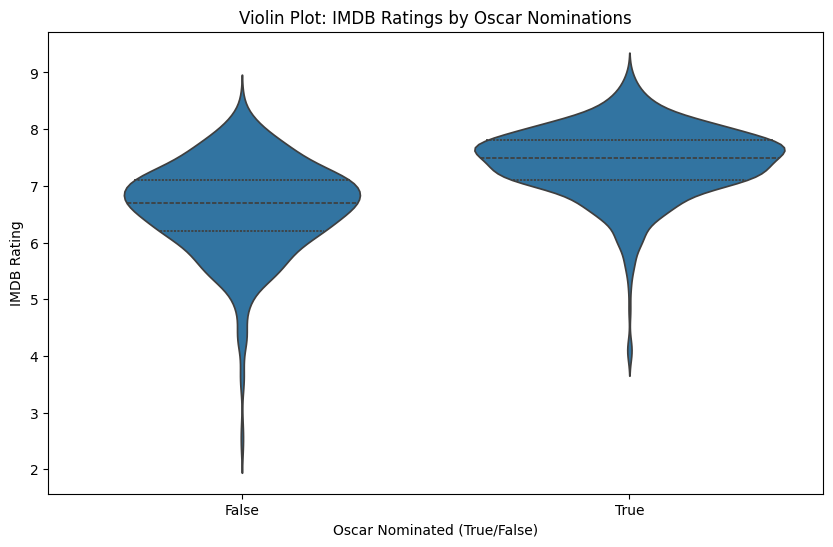

In [150]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Oscar_nominations', y='rate', data=exploration_1_movie_df, inner='quartile')
plt.title('Violin Plot: IMDB Ratings by Oscar Nominations')
plt.xlabel('Oscar Nominated (True/False)')
plt.ylabel('IMDB Rating')
plt.show()

Does getting Nominated for an Oscar affect ratings in specific genres?
We'll analyze the relationship within the 'Drama' genre for better insights.


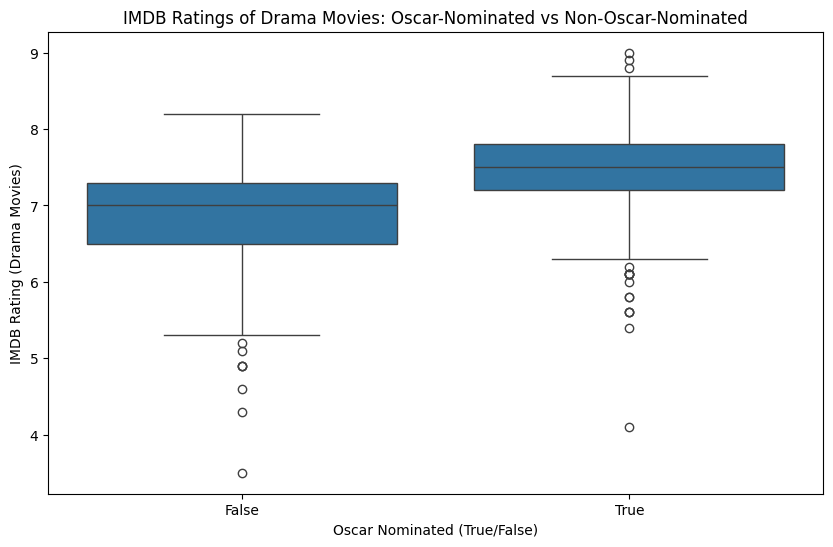

T-statistic (Drama Movies): 12.222206881793293, P-value (Drama Movies): 3.922383258659558e-31
There is a statistically significant difference in ratings for Drama movies between Oscar-Nominated and non-Oscar-Nominated movies.


In [151]:
drama_movies = exploration_1_movie_df[exploration_1_movie_df['genre'].apply(lambda genres: 'Drama' in genres)]

# Comparing IMDB ratings for drama movies that got 0 nominations vs those that got 1 or more nominations
oscar_nom_drama = drama_movies[drama_movies['Oscar_nominations'] == True]['rate']
non_oscar_nom_drama = drama_movies[drama_movies['Oscar_nominations'] == False]['rate']

# Plot comparison within the Drama genre
plt.figure(figsize=(10, 6))
sns.boxplot(x='Oscar_nominations', y='rate', data=drama_movies)
plt.title('IMDB Ratings of Drama Movies: Oscar-Nominated vs Non-Oscar-Nominated')
plt.xlabel('Oscar Nominated (True/False)')
plt.ylabel('IMDB Rating (Drama Movies)')
plt.show()

# Perform T-test for Drama movies
t_stat_drama, p_val_drama = stats.ttest_ind(oscar_nom_drama, non_oscar_nom_drama, nan_policy='omit')

print(f"T-statistic (Drama Movies): {t_stat_drama}, P-value (Drama Movies): {p_val_drama}")

if p_val_drama < 0.05:
    print("There is a statistically significant difference in ratings for Drama movies between Oscar-Nominated and non-Oscar-Nominated movies.")
else:
    print("There is no statistically significant difference in ratings for Drama movies between Oscar-Nominated and non-Oscar-Nominated movies.")

Key Conclusions:
1. Oscar-nominated movies tend to have higher IMDB ratings, as seen in both the density plot and boxplot.
2. Oscar nominations have a statistically significant impact on movie ratings, as confirmed by the T-test.
3. The violin plot further supports the trend of higher IMDB ratings for Oscar-nominated movies compared to non-nominated ones.
4. In the "Drama" genre, Oscar nominations also show a significant impact on ratings, suggesting that nomination prestige affects audience perception.

### Exploration 2

**First, let's determine if there are significant differences in gross profits among the movie certificates.**

The null hypothesis is, of course, that there are no significant differences in gross profits among the movie certificates.
Then the alternative hypothesis is that there *are* significant differences in gross profits among the movie certificates.

In [152]:
import matplotlib.ticker as ticker # This is required for setting our X-axis below. 

In [153]:
exploration_2_movie_df = movie_df.copy()

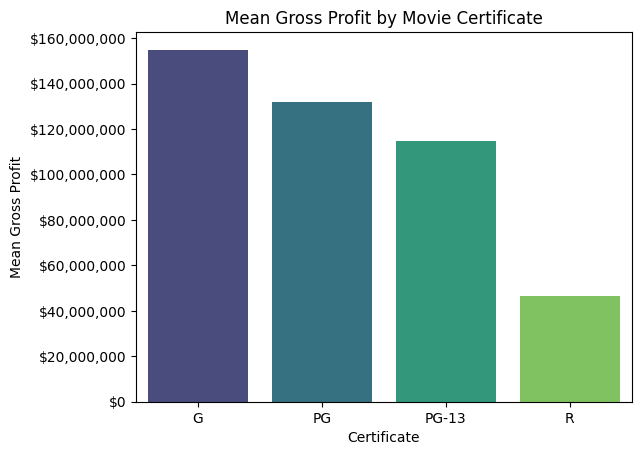

In [154]:
filtered_df = exploration_2_movie_df[exploration_2_movie_df['certificate'].isin(['G', 'PG', 'PG-13', 'R'])]
filtered_df = filtered_df.dropna(subset=['gross'])

mean_gross_by_certificate = filtered_df.groupby('certificate')['gross'].mean().reset_index()

plt.figure()
sns.barplot(x='certificate', y='gross', data=mean_gross_by_certificate, palette='viridis', hue='certificate', legend=False)

plt.xlabel('Certificate')
plt.ylabel('Mean Gross Profit')
plt.title('Mean Gross Profit by Movie Certificate')

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

plt.show()


**Performing an ANOVA Test to Find the p-value of the Hypothesis:**

In [155]:
groups = [filtered_df[filtered_df['certificate'] == cert]['gross'].dropna() for cert in ['G', 'PG', 'PG-13', 'R']]
f_statistic, p_value = stats.f_oneway(*groups)

print(f'p-value: {p_value}')

p-value: 4.755963268634168e-35


**Conclusion: As the p-value is less than alpha (in this case, 0.05), we weject the null hypothesis; There are significant differences in gross profits among the movie certificates.**

Next, another question.

Our null hypothesis is that R-rated movies do not yield significantly less gross profit than other movie categories.
Then the alternative hypothesis is that they *do* yield significantly less gross profit than other movie categories.

In [156]:
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [157]:
tukey_result = pairwise_tukeyhsd(endog=filtered_df['gross'], groups=filtered_df['certificate'], alpha=0.05)

print(tukey_result)

           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
group1 group2     meandiff    p-adj       lower          upper      reject
--------------------------------------------------------------------------
     G     PG  -22991261.1356 0.7542  -82642137.5323  36659615.2611  False
     G  PG-13  -40022813.7608 0.2676  -96815111.4164  16769483.8948  False
     G      R -108163754.8717    0.0 -164908134.9033   -51419374.84   True
    PG  PG-13  -17031552.6252 0.2606  -41002479.1967   6939373.9464  False
    PG      R   -85172493.736    0.0 -109029671.1231  -61315316.349   True
 PG-13      R  -68140941.1109    0.0  -83513089.0084 -52768793.2133   True
--------------------------------------------------------------------------


Main Conclusion:
- The Tukey HSD Test reveals that the p-adj values for each comparison made between R-rated films and other groups is less than alpha (0.05 in this case), so we reject the null hypothesis; R-rated movies yield significantly less gross profit than other movie categories.

### Exploration 3

In [158]:
from scipy.stats import pearsonr

In [159]:
exploration_3_movie_df = movie_df.copy()

In [160]:
# Dropping NaN to be able to perform Pearson
exploration_3_movie_df = exploration_3_movie_df[['duration', 'rate', 'metascore']].dropna()

# Pearson correlation for runtime vs rating
corr_rating, p_value_rating = pearsonr(exploration_3_movie_df['duration'], exploration_3_movie_df['rate'])

# Pearson correlation for runtime vs metascore
corr_metascore, p_value_metascore = pearsonr(exploration_3_movie_df['duration'], exploration_3_movie_df['metascore'])

print(f"Correlation between runtime and rating: {corr_rating}, p-value: {p_value_rating}")
print(f"Correlation between runtime and metascore: {corr_metascore}, p-value: {p_value_metascore}")

Correlation between runtime and rating: 0.28917156295091134, p-value: 5.94615651276181e-24
Correlation between runtime and metascore: 0.1587500374135552, p-value: 4.8534802753441075e-08


In [161]:
exploration_3_movie_df['metascore'] = exploration_3_movie_df['metascore'].astype('int64')

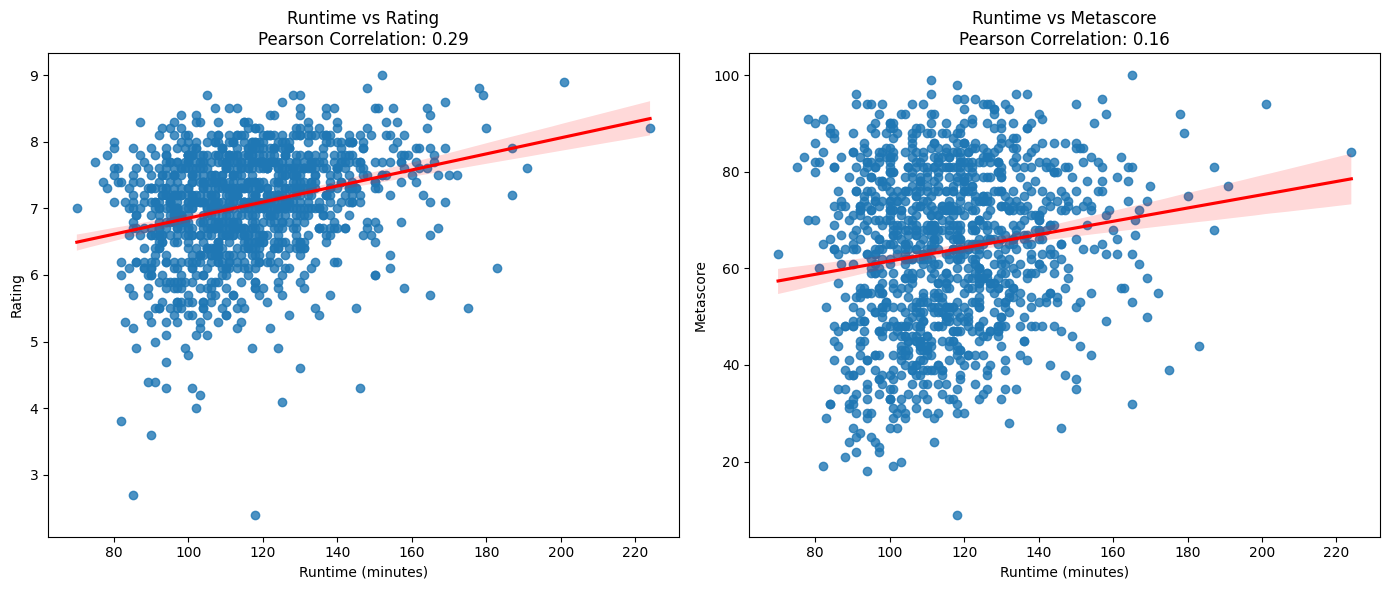

In [162]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Runtime vs Rating
sns.regplot(ax=axes[0], x='duration', y='rate', data=exploration_3_movie_df, scatter=True, line_kws={"color": "red"})
axes[0].set_title(f'Runtime vs Rating\nPearson Correlation: {corr_rating:.2f}')
axes[0].set_xlabel('Runtime (minutes)')
axes[0].set_ylabel('Rating')

# Plot 2: Runtime vs Metascore
sns.regplot(ax=axes[1], x='duration', y='metascore', data=exploration_3_movie_df, scatter=True, line_kws={"color": "red"})
axes[1].set_title(f'Runtime vs Metascore\nPearson Correlation: {corr_metascore:.2f}')
axes[1].set_xlabel('Runtime (minutes)')
axes[1].set_ylabel('Metascore')

plt.tight_layout()
plt.show()

Key Conclusions:
- Given the Pearson Correlation coefficient for Duration and Rate of 0.29 with an incredibly low p-value, there is some positive correlation between the two variables, albeit somewhat weak. With the plot and trendline, this notion is reinforced that there is some correlation between the rating and duration.
- Looking at the Pearson Correlation coefficient for Duration and Metascore, there is a weak positive correlation between the two given the low coefficient. It is also weaker than the relationship between the rating as well. It is important to note the caveat that the range of choices for rating and metascore may be influencing this, as rating is able to cluster more given it can only be a number 1-10, while metascore can be a number 1-100.
- Either way, given the Pearson correlation between Duration, Rate, and Metascore, there is some positive relationship that can be investigated further.

### Observations

## Primary Analysis

### Data Preparation

We already did a lot of data preprocessing above, but in order to genre analysis, we should break the list of genres into boolean features for ease of analysis. For example, if the movie has "Action" in its list of genres, we want a 1 in the *Action* Column. This technique is called One-Hot Encoding.

In [177]:
# In an earlier code block, we already got a complete list of all genres represented in our data, called sorted_genres

for genre in sorted_genres:
    movie_df[genre] = movie_df['genre'].apply(lambda x: 1 if genre in x else 0)

print(movie_df[sorted_genres].head())

   Action  Adventure  Animation  Biography  Comedy  Crime  Documentary  Drama  \
0       0          0          0          0       1      0            0      0   
1       0          1          1          0       1      0            0      0   
2       1          1          0          0       0      0            0      0   
3       0          0          0          1       0      0            0      1   
4       0          1          0          0       0      0            0      1   

   Family  Fantasy  ...  Horror  Music  Musical  Mystery  Romance  Sci-Fi  \
0       0        1  ...       0      0        0        0        1       0   
1       0        0  ...       0      0        0        0        0       0   
2       1        0  ...       0      0        0        0        0       0   
3       0        0  ...       0      0        0        0        1       0   
4       0        1  ...       0      0        0        0        0       0   

   Sport  Thriller  War  Western  
0      0       

### Select Target and Features

Target Variable: We need to identify the target variable we want to predict. For now, we will start with the crème de la crème, the Oscar best picture nomination.

Features: We can use the one-hot encoded genre columns (Action, Adventure, etc.) as predictors

### Split Data into Train/Test Sets

Split the dataset into training and testing sets to ensure proper model evaluation

In [178]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = movie_df[sorted_genres]  # One-hot encoded genres
y = movie_df['Oscar_Best_Picture_nominated']  # Target variable

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Training size: (946, 22)
Test size: (237, 22)


### Train a Classification Model

Train a classification model to predict whether a movie will win an Oscar based on its genre.

In this case, we will use Logistic Regression to interpret probabilities and feature importance.

We chose logistic regression because it is a simple yet effective model for binary classification, allowing us to interpret the importance of features like genres and ratings in predicting Oscar nominations.

In [181]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train the logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0.0))

Accuracy: 0.9113924050632911
Classification Report:
              precision    recall  f1-score   support

       False       0.91      1.00      0.95       216
        True       0.00      0.00      0.00        21

    accuracy                           0.91       237
   macro avg       0.46      0.50      0.48       237
weighted avg       0.83      0.91      0.87       237



### Analysis of Results


#### Limitations:
1.   High Accuracy but Impalanced Predictions

        The accuracy displayed is **91%**, which may seem high, but upon inspecting the Classification Report we see that the model predicts only one class (False) with great precision, completely ignoring the True class. The imbalance can be attributed to the dataset's skewed distribtuion: out of 237 test samples, only 21 belong to the True class.
2.   Limited Data

        There is a limited amount of data for Best Picture nominations, since the dataset spans only 17 years with only 5 nominations per year. The limited data prevents the model from learning patterns to accurately identify.
3.   Limited Features

Model is based solely on genres, which may not be sufficient since each movie only has about 3 genres at most. This restricts the variety of input data


#### Solutions:
1.   Look at other categories
2.   Incorporate additional features






Just for fun, let us test this version of the model on movies past 2017. We know for a fact that last year, Oppenheimer was nominated for Best Picture and my favorite movie, The Holdovers, was not (#robbed). Let's create a function that uses our model and predicts the movies.

In [166]:
# Define a function to predict a new movie
def predict_oscar_nomination(movie_genres):
    # Create a dictionary for the new movie's genre features
    new_movie = {genre: 1 if genre in movie_genres else 0 for genre in X.columns}

    # Convert the dictionary to a DataFrame (single-row input for prediction)
    new_movie_df = pd.DataFrame([new_movie])

    # Predict using the trained model
    prediction = model.predict(new_movie_df)
    prediction_prob = model.predict_proba(new_movie_df)

    # Return the prediction and probabilities
    return prediction[0], prediction_prob[0]

# Test on Oppenheimer (genres: Biography, Drama, History)
oppenheimer_genres = ['Biography', 'Drama', 'History']
oppenheimer_prediction, oppenheimer_prob = predict_oscar_nomination(oppenheimer_genres)
print("Oppenheimer Prediction:", oppenheimer_prediction)
print("Oppenheimer Probabilities:", oppenheimer_prob)

# Test on The Holdovers (genres: Comedy, Drama)
holdovers_genres = ['Comedy', 'Drama']
holdovers_prediction, holdovers_prob = predict_oscar_nomination(holdovers_genres)
print("The Holdovers Prediction:", holdovers_prediction)
print("The Holdovers Probabilities:", holdovers_prob)

Oppenheimer Prediction: False
Oppenheimer Probabilities: [0.61042991 0.38957009]
The Holdovers Prediction: False
The Holdovers Probabilities: [0.82884217 0.17115783]


Clearly wrong. Let's try something else!

### Redoing with more features

Repeat the same steps and do Logistic Regression on new features *rate, metascore, duration,* and *popularity*

In [167]:
# Define features (X) and target (y)
numerical_features = ['rate', 'metascore', 'votes', 'duration', 'popularity']
X = movie_df[sorted_genres + numerical_features]  # Use sorted_genres for genres

y = movie_df['Oscar_Best_Picture_nominated']  # Target variable

# Handle missing values in numerical features
X[numerical_features] = X[numerical_features].fillna(X[numerical_features].median())

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

C:\Users\rmhop\AppData\Local\Temp\ipykernel_5784\2725447303.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[numerical_features] = X[numerical_features].fillna(X[numerical_features].median())


Accuracy: 0.9282700421940928

Classification Report:
              precision    recall  f1-score   support

       False       0.93      1.00      0.96       216
        True       0.83      0.24      0.37        21

    accuracy                           0.93       237
   macro avg       0.88      0.62      0.67       237
weighted avg       0.92      0.93      0.91       237



c:\Users\rmhop\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Much better!

**Overall accuracy: 92.4%**

Great, but not all the story


**Classification Report:**

The model now performs better at identifying nominations but still struggles with the minority class. Precision for True improved significantly, but recall needs further enhancement (e.g., oversampling, better features). The added features provided meaningful improvements, but the dataset's imbalance limits the model's ability to generalize.


### Redoing with more features AND new target

Repeat the same steps and do Logistic Regression on new features *rate, metascore, duration,* and *popularity*. This time, we will do the model on a new target, which is whether or not the movie was nominated for an Oscar at all, not just Best Picture.

In [168]:
#Using the same code as above, we preprocess by adding a feature saying whether they were nominated for ANY Oscar

movie_df['Oscar_nominations'] = movie_df['Oscar_nominated'] > 0
display(movie_df[['Oscar_nominated', 'Oscar_nominations']])

,Oscar_nominated,Oscar_nominations
0,1,True
1,0,False
2,0,False
3,6,True
4,13,True
...,...,...
1178,4,True
1179,6,True
1180,2,True
1181,1,True


In [169]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


# Define features (X) and the new target (y)
numerical_features = ['rate', 'metascore', 'votes', 'duration', 'popularity']
X = movie_df[sorted_genres + numerical_features]  # Use genres + numerical features as predictors
y = movie_df['Oscar_nominations']  # New target variable

# Handle missing values in numerical features
X[numerical_features] = X[numerical_features].fillna(X[numerical_features].median())

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

C:\Users\rmhop\AppData\Local\Temp\ipykernel_5784\661078431.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[numerical_features] = X[numerical_features].fillna(X[numerical_features].median())


Accuracy: 0.7721518987341772

Classification Report:
              precision    recall  f1-score   support

       False       0.82      0.70      0.75       119
        True       0.74      0.85      0.79       118

    accuracy                           0.77       237
   macro avg       0.78      0.77      0.77       237
weighted avg       0.78      0.77      0.77       237



c:\Users\rmhop\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Analysis: The model got a decent performance with an accuracy of 79% and a comparable F1-score for both classes (True and False), indicating it performs reasonably good at predicting whether a movie received any Oscar nominations. However, it achieved slightly lower precision for True (75%) and recall for False (71%), meaning there is room for improvement in identifying each class accurately. We balanced the True/False data, but there can still be more features to model on.

### New Scenario:

Let's say you are a director, but you don't care about the Oscars at all! You only care about the rating of the movie, the metascore, and the gross amount it makes.

Here we will use MultiOutputRegressor to model all three outputs.

In [170]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and targets (y)
X = movie_df[sorted_genres]  # Genres as features
y = movie_df[['rate', 'metascore', 'gross']]  # Multi-target regression

# Handle missing values in target variables
y = y.fillna(y.median())

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the multi-output regressor
regressor = MultiOutputRegressor(RandomForestRegressor(random_state=42))
regressor.fit(X_train, y_train)

# Make predictions
y_pred = regressor.predict(X_test)

# Evaluate the model
for i, target in enumerate(y.columns):
    print(f"Evaluation for {target}:")
    mse = mean_squared_error(y_test.iloc[:, i], y_pred[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"R^2 Score: {r2:.2f}")
    print("-" * 50)

Evaluation for rate:
Mean Squared Error: 0.54
R^2 Score: 0.02
--------------------------------------------------
Evaluation for metascore:
Mean Squared Error: 255.56
R^2 Score: 0.12
--------------------------------------------------
Evaluation for gross:
Mean Squared Error: 5538193216652837.00
R^2 Score: 0.34
--------------------------------------------------


The model's poor performance (e.g., R^2 scores of 0.02 for rate, 0.12 for metascore, and 0.34 for gross) shows that genres alone are **insufficient** for predicting these outcomes, as critical factors like director, budget, and release date, rating, etc. are missing. Adding more features and using advanced models could better capture the complexity of these relationships. Also, movie success is rather unexplainable!

Let's put our model to the test with a new movie, Megalopolis, by Francis Ford Coppola of The Godfather fame. 

In [171]:
# Define a function to predict rate, metascore, and gross for a new movie
def predict_movie_outcomes(movie_genres):
    # Create a dictionary for the new movie's genre features
    new_movie = {genre: 1 if genre in movie_genres else 0 for genre in sorted_genres}

    # Convert the dictionary to a DataFrame (single-row input for prediction)
    new_movie_df = pd.DataFrame([new_movie])

    # Predict using the trained model
    predictions = regressor.predict(new_movie_df)

    # Extract predictions for each target
    predicted_rate, predicted_metascore, predicted_gross = predictions[0]

    # Return the predictions as a dictionary
    return {
        "Rate": round(predicted_rate, 2),
        "Metascore": round(predicted_metascore, 2),
        "Gross": f"${round(predicted_gross, 2):,.2f}"
    }

# Test the function on Megalopolis (genres: Drama, Sci-Fi, Thriller)
megalopolis_genres = ['Drama', 'Sci-Fi', 'Thriller']
megalopolis_predictions = predict_movie_outcomes(megalopolis_genres)
print("Predictions for Megalopolis:", megalopolis_predictions)


Predictions for Megalopolis: {'Rate': 6.91, 'Metascore': 56.28, 'Gross': '$38,865,610.11'}


Mega**FLOP**olis actually made 12.5 gross in real life and stands at a 4.9 rating on IMDB, so our model clearly overestimates the movie's success.

Our model is very limited with just analyzing genre. It is clear that multiple movies from the same genre combinations can perform very differently. Adding more features to the mix will give us more accurate predictions.

Additionally, our model is *only* trained on movies that were nominated for an Oscar or received another award, so they're probably good movies, so they probably do well! Megalopolis is a *very bad* movie. Even with the best models, if you're using it on the wrong data, you'll be left with bad results no matter what! 

## Visualization

## Insights & Conclusions